<h2 id="analiza-opisowa">3. Analiza opisowa</h2>

W tej sekcji przeprowadzamy ilościową analizę danych, obliczając podstawowe statystyki opisowe. Wyniki przedstawiamy w tabelach wraz z krótką interpretacją. Zaczniemy od wczytania bibliotek i danych.

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv('data/sklep_rowerowy_oczyszczone.csv')

### Analiza 1: Statystyki dochodów w podziale na kupujących i niekupujących

In [2]:
income_stats = df.groupby('Purchased Bike')['Income'].agg([
    ('Liczebność', 'count'),
    ('Średnia', 'mean'),
    ('Mediana', 'median'),
    ('Odch. std.', 'std'),
    ('Minimum', 'min'),
    ('Maksimum', 'max')
]).round(0)

income_stats

,Liczebność,Średnia,Mediana,Odch. std.,Minimum,Maksimum
Purchased Bike,,,,,,
No,519,54875.0,60000.0,31136.0,10000,170000
Yes,481,57817.0,60000.0,30761.0,10000,170000


Średni dochód w grupie kupujących (57 817 USD) jest nieznacznie wyższy niż w grupie niekupujących (54 875 USD). Różnica wynosi około 2 942 USD, co stanowi niewielką różnicę. Mediana dochodu w obu grupach jest identyczna (60 000 USD), a rozrzut dochodów jest podobny. Oznacza to, że dochód nie jest kluczowym czynnikiem różnicującym te grupy - zarówno wśród kupujących, jak i niekupujących znajdują się osoby o różnych dochodach.

### Analiza 2: Statystyki wieku w podziale na kupujących i niekupujących

In [3]:
age_stats = df.groupby('Purchased Bike')['Age'].agg([
    ('Liczebność', 'count'),
    ('Średnia', 'mean'),
    ('Mediana', 'median'),
    ('Odch. std.', 'std'),
    ('Minimum', 'min'),
    ('Maksimum', 'max')
]).round(1)

age_stats

,Liczebność,Średnia,Mediana,Odch. std.,Minimum,Maksimum
Purchased Bike,,,,,,
No,519,45.3,44.0,12.3,25,89
Yes,481,42.9,41.0,10.1,25,78


Średni wiek osób, które kupiły rower, wynosi 42.9 lat i jest o 2.4 lat niższy niż w grupie niekupujących (45.3 lat). Mediana wieku w grupie kupujących to 41.0 lat, podczas gdy w grupie niekupujących 44.0 lat - różnica wynosi 3 lata. W grupie niekupujących występuje większe zróżnicowanie wieku (odchylenie standardowe 12.3 vs 10.1). Najmłodsza osoba w obu grupach ma 25 lat, natomiast najstarsza w grupie kupujących ma 78 lat, a w grupie niekupujących 89 lat. Oznacza to, że młodsi klienci nieznacznie częściej decydują się na zakup roweru, ale różnica nie jest duża - rowery są atrakcyjne dla osób w każdym wieku.

### Analiza 3: Wykształcenie a zakup roweru (procentowy udział)

In [4]:
education_bike = pd.crosstab(df['Education'], df['Purchased Bike'], normalize='index') * 100
education_bike = education_bike.round(1)

education_counts = pd.crosstab(df['Education'], df['Purchased Bike'])
education_bike['Liczba osób'] = education_counts.sum(axis=1)

education_bike = education_bike.sort_values(by='Yes', ascending=False)

education_bike

Purchased Bike,No,Yes,Liczba osób
Education,,,
Bachelors,44.8,55.2,306
Graduate Degree,46.0,54.0,174
Partial College,55.1,44.9,265
High School,55.9,44.1,179
Partial High School,73.7,26.3,76


Osoby z wyższym wykształceniem (Graduate Degree) najczęściej kupują rowery - 54.0% z nich dokonało zakupu. Najrzadziej rowery kupują osoby z podstawowym wykształceniem (Partial High School) - tylko 26.3%.

Zaobserwowana zależność sugeruje, że wykształcenie pośrednio wpływa na decyzję zakupową, co może wynikać z wyższych dochodów wśród osób lepiej wykształconych oraz większej świadomości zdrowotnej.

### Analiza 4: Miary zmienności, skośności i kurtozy

In [6]:
from scipy.stats import skew, kurtosis

# Obliczenie miar kształtu rozkładu
miary_ksztaltu = pd.DataFrame({
    'Zmienna': ['Income', 'Age', 'Children', 'Cars'],
    'Średnia': df[['Income', 'Age', 'Children', 'Cars']].mean(),
    'Odch. std.': df[['Income', 'Age', 'Children', 'Cars']].std(),
    'Skośność': df[['Income', 'Age', 'Children', 'Cars']].skew(),
    'Kurtoza': df[['Income', 'Age', 'Children', 'Cars']].kurt()
})
miary_ksztaltu

,Zmienna,Średnia,Odch. std.,Skośność,Kurtoza
Income,Income,56290.000,30975.722678,0.751168,0.536173
Age,Age,44.172,11.316912,0.527930,-0.237926
Children,Children,1.911,1.620403,0.393232,-1.003227
Cars,Cars,1.451,1.117519,0.429246,-0.376176


**Skośność**:
  - Wartość dodatnia - prawostronna asymetria (długi ogon po prawej stronie)
  - Wartość ujemna - lewostronna asymetria (długi ogon po lewej stronie)
  - Wartość bliska 0 - rozkład symetryczny

**Kurtoza**:
  - Dodatnia (>0) oznacza rozkład leptokurtyczny (ostry szczyt, grube ogony)
  - Ujemna (<0) oznacza rozkład platykurtyczny (płaski szczyt, cienkie ogony)
  - Bliska 0 oznacza rozkład mezokurtyczny (podobny do normalnego)

**Wnioski**

Income wykazuje największą asymetrię i najbardziej "grube ogony" - oznacza to, że w zbiorze danych występują klienci o bardzo wysokich dochodach, którzy mogą stanowić odrębną grupę nabywców.
Age ma rozkład najbardziej zbliżony do normalnego - klienci są dość równomiernie rozłożeni w przedziale wiekowym.
Children i Cars mają ujemną kurtozę, co oznacza, że wartości są równomiernie rozłożone, bez wyraźnego skupienia wokół jednej wartości.

### Analiza 4.2 Histogramy rozkładu

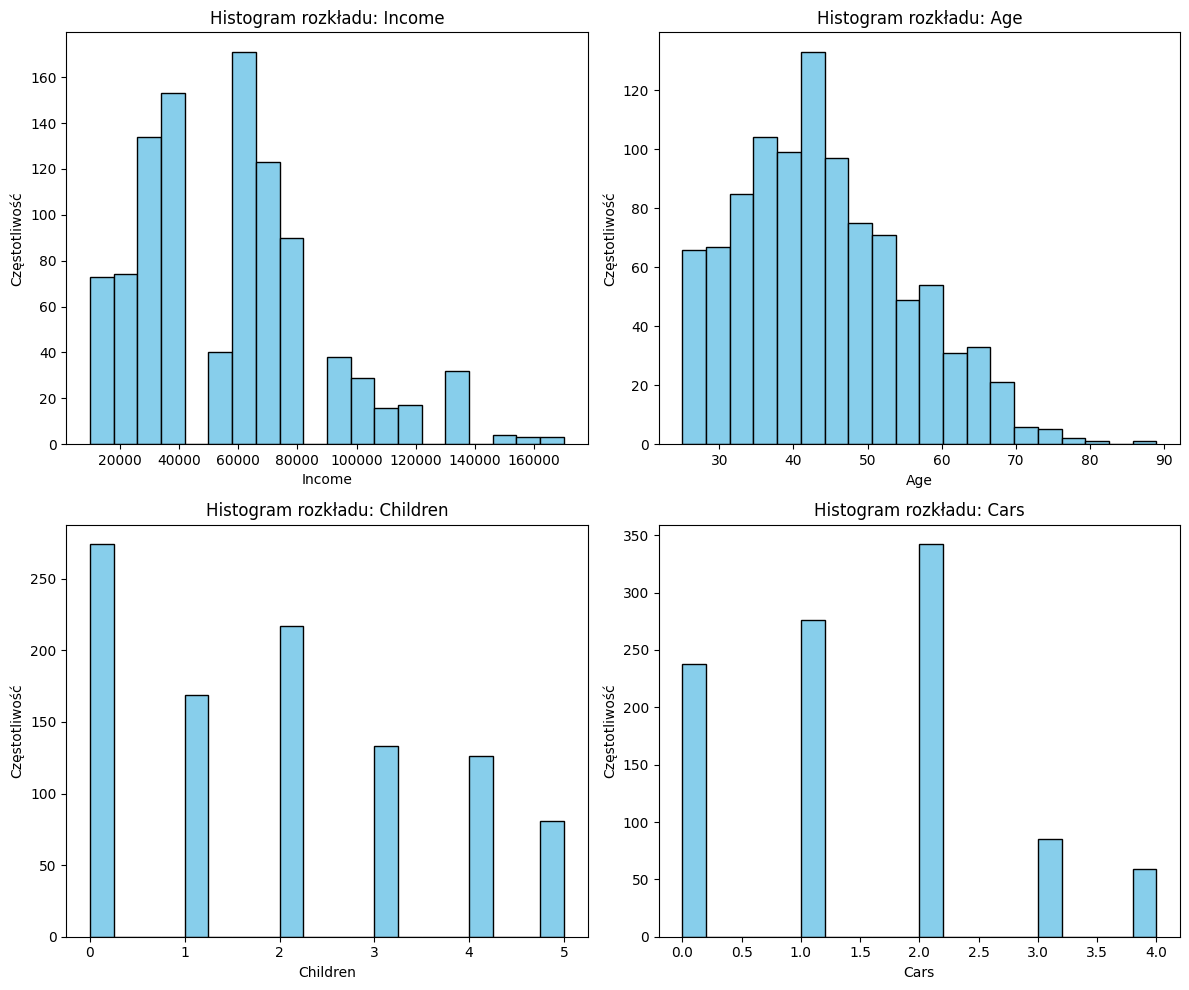

In [13]:
kolumny = ['Income', 'Age', 'Children', 'Cars']

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

for i, col in enumerate(kolumny):
    axes[i].hist(df[col].dropna(), bins=20, color='skyblue', edgecolor='black')
    axes[i].set_title(f'Histogram rozkładu: {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Częstotliwość')

plt.tight_layout()
plt.show()

Dodatkowo załączamy histogramy, w jaki sposób prezentują się rozkłady danych o klientach sklepu rowerowego.